# Neural Networks: Assignment week 3
Nea Lukumies

Assignment instructions: https://github.com/kopuj/neuralNetworks/blob/master/Assignments/Assignment_week3.md

The data is the CIFAR-10 dataset that consists of 60 000 32x32 color images in 10 classes, with 6000 images per class. The dataset is divided into training, validation and test sets. The training set contains 40 000 images and both the validation set and test set contains 10 000 images. The classes are: airplane, automobile, bird, cat, deer, dog, frog, horse, ship and truck.

The goal is to use a pretrained convolutional base and train the Dense layer on top of it to classify images in the CIFAR-10 dataset. 

In [4]:
import keras
from keras import layers, Input
from keras.applications import MobileNetV2
from keras.models import Sequential
from keras.layers import Flatten, Dense, Dropout
from keras.optimizers import Adam, SGD
import matplotlib.pyplot as plt
from keras.callbacks import EarlyStopping
from keras.applications.mobilenet_v2 import preprocess_input
import tensorflow as tf
import numpy as np

batch_size = 32 # number of images in each batch
img_size = (32, 32) # 32 x 32 pixel images in input data

train_dataset, validation_dataset = keras.utils.image_dataset_from_directory(
    './data/train',
    batch_size=batch_size, 
    image_size=img_size,
    label_mode='categorical',
    validation_split=0.2, 
    subset='both',
    seed=123)

test_dataset = keras.utils.image_dataset_from_directory(
    './data/test',
    batch_size=batch_size, 
    image_size=img_size,
    label_mode='categorical')



Found 50000 files belonging to 10 classes.
Using 40000 files for training.
Using 10000 files for validation.
Found 10000 files belonging to 10 classes.


The convolutional base is frozen, which means that the weights of the convolutional layers will not be updated during training. This way, only the new Dense classifier on top will be trained on the CIFAR-10 dataset. So when the Dense top is set to include_top=False, the fully connected layers of pretrained networks are excluded and only the convolutional layers are used. conv_base.trainable = False freezes the convolutional base, preventing its weights from being updated during training. 

Both the VGG16 and MobileNetV2 convolutional bases were tested. At first the input images were not resized, but that resulted in models that basically guessed the predictions (10-20% accuracy). Models were tested with 96x96 and 128x128 input sizes with different sized Dense layers on top and with different learning rates, dropout, epoch and batch sizes. Flatten() and GlobalAveragePooling2D() were also tested as the layer before the Dense layers. For the optimizer, Adam was used, but SGD with momentum was also tested. Adam was chosen with slightly better results and faster training times.

The resulting accuracies were in their 70s with the best model achieving 79% validation and test accuracy. None of the models were showing signs of overfitting, but training times were quite long which waslimiting the experimentations further. The best model was achieved with MobileNetV2 convolutional base, 128x128 input size, Flatten() before the Dense layers, 256 units in the Dense layer, dropout of 0.5 and learning rate of 0.0001. Early stopping was used to stop the training when the validation loss stopped improving for 5 epochs. 

In [5]:
def preprocess(x, y):
    x = tf.image.resize(x, (128, 128))
    x = preprocess_input(x)
    return x, y

preprocessed_train_dataset = train_dataset.map(preprocess)
preprocessed_validation_dataset = validation_dataset.map(preprocess)
preprocessed_test_dataset = test_dataset.map(preprocess)

In [6]:
conv_base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(128, 128,3))
conv_base.trainable = False

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

model = Sequential([
    Input(shape=(128,128,3)),    
    data_augmentation,
    conv_base,
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

optimizer = Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    preprocessed_train_dataset,
    validation_data=preprocessed_validation_dataset,
    epochs=50,
    callbacks=[early_stop],
    verbose=0
)


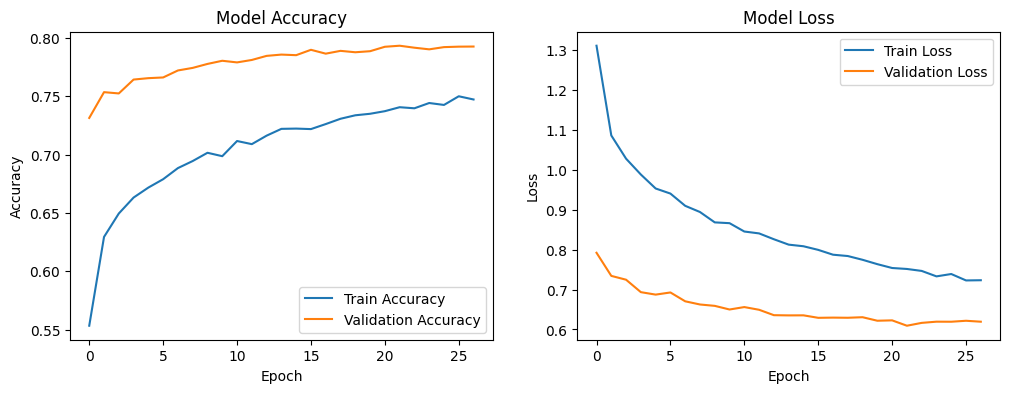

In [7]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [11]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 20480)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     5,243,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,995,104 (68.65 MB)

 Trainable params: 5,245,706 (20.01 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 10,491,414 (40.02 MB)

In [8]:
test_loss, test_accuracy = model.evaluate(preprocessed_test_dataset)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 57s 180ms/step - accuracy: 0.7906 - loss: 0.6030
Test Loss: 0.6030
Test Accuracy: 0.7906


The final test accuracy of the best model was 79.15% which is a fairly good result for a model that is only training the Dense layer on top of the convolutional base. Looking at the curves the training and validation accuracies are not getting that much better after the first 10-15 epochs so the early stopping could have been set to stop earlier as training time was quite long. 

The model is able to learn to classify the images in the CIFAR-10 dataset with a good level of accuracy, and below is seen first a few examples of prediction (randomly selected from the test set) and below a set of only wrong predictions. In this testing there are no clear patterns in the wrong predictions as with previous assignments and the model seems to struggle with all classes to some extent. 

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


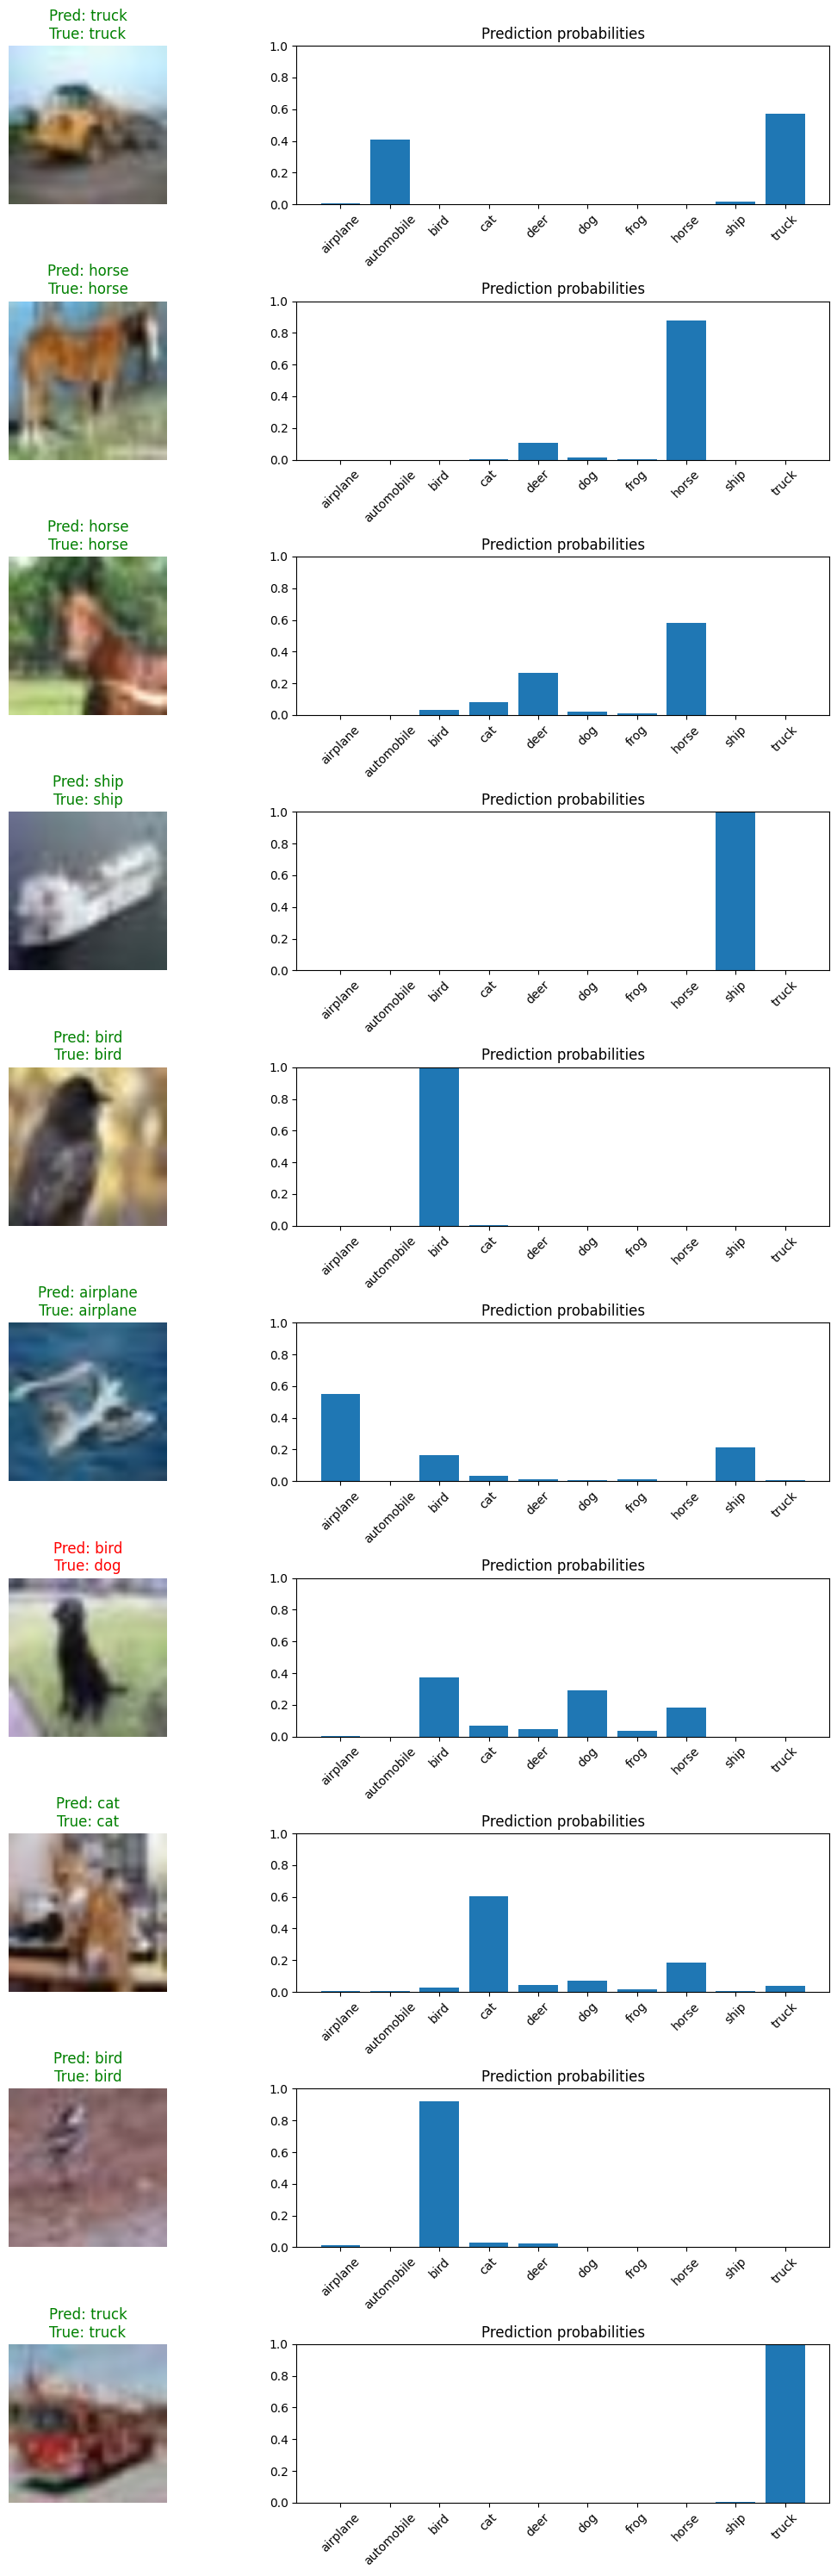

In [9]:
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

for images, labels in preprocessed_test_dataset.take(1):
    preds = model.predict(images)
    
    num_images = 10
    plt.figure(figsize=(12, num_images * 3))
    
    for i in range(num_images):
        
        plt.subplot(num_images, 2, 2*i + 1)
        
        img = (images[i].numpy() + 1) / 2  # rescale
        true_label = np.argmax(labels[i])
        pred_label = np.argmax(preds[i])
        
        plt.imshow(img)
        plt.axis('off')
        
        color = 'green' if true_label == pred_label else 'red'
        
        plt.title(
            f"Pred: {class_names[pred_label]}\nTrue: {class_names[true_label]}",
            color=color
        )

        plt.subplot(num_images, 2, 2*i + 2)
        
        plt.bar(range(10), preds[i])
        plt.xticks(range(10), class_names, rotation=45)
        plt.ylim([0,1])
        plt.title("Prediction probabilities")
    
    plt.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step


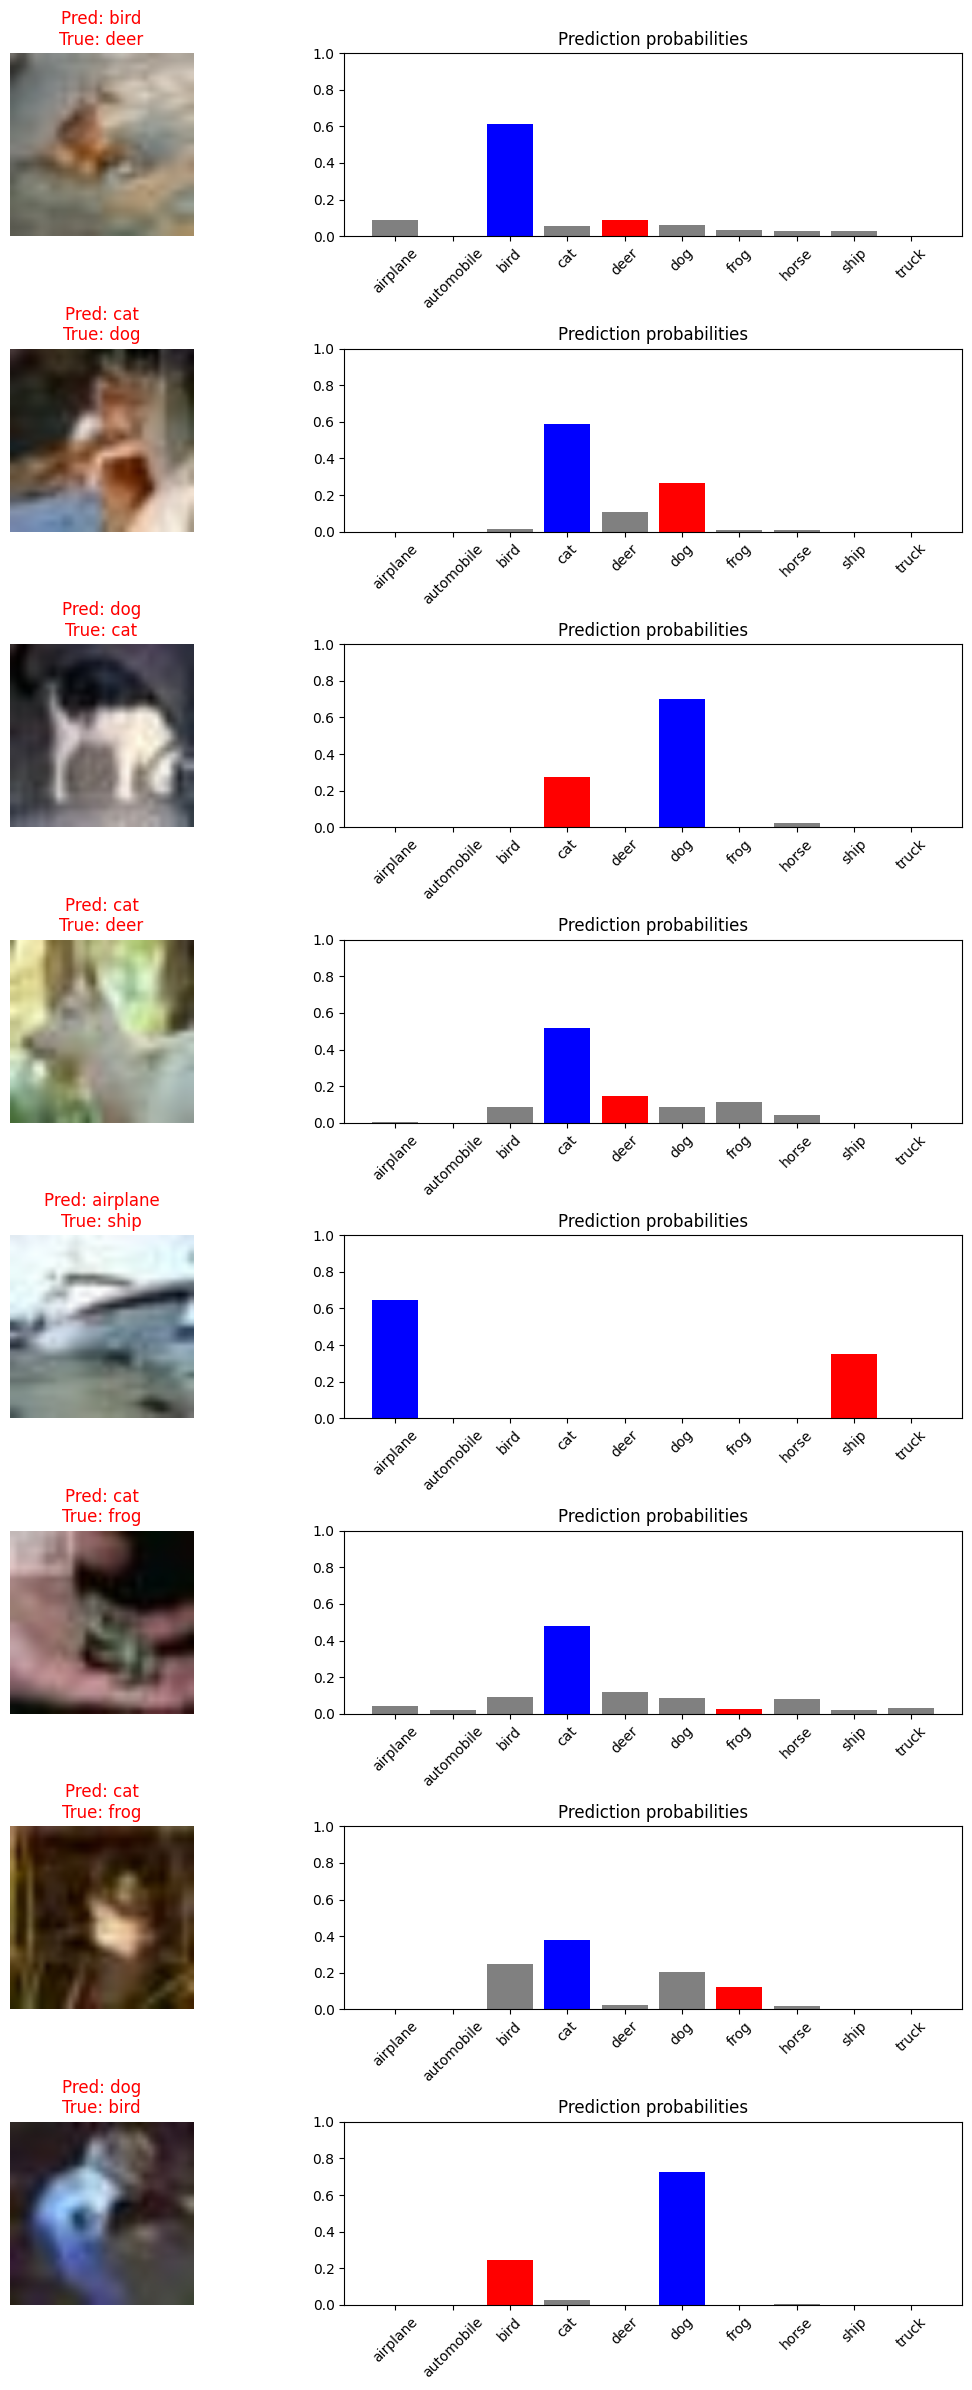

In [10]:

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

for images, labels in preprocessed_test_dataset.take(1):
    preds = model.predict(images)
    
    true_labels = np.argmax(labels, axis=1)
    pred_labels = np.argmax(preds, axis=1)
    
    wrong_indices = np.where(true_labels != pred_labels)[0]
    
    num_show = min(10, len(wrong_indices)) 
    
    plt.figure(figsize=(12, num_show * 3))
    
    for i in range(num_show):
        idx = wrong_indices[i]

        plt.subplot(num_show, 2, 2*i + 1)
        
        img = (images[idx].numpy() + 1) / 2
        true_label = true_labels[idx]
        pred_label = pred_labels[idx]
        
        plt.imshow(img)
        plt.axis('off')
        
        plt.title(
            f"Pred: {class_names[pred_label]}\nTrue: {class_names[true_label]}",
            color='red'
        )

        plt.subplot(num_show, 2, 2*i + 2)
        
        colors = ['gray'] * 10
        colors[pred_label] = 'blue'   # predicted
        colors[true_label] = 'red'    # true
        
        plt.bar(range(10), preds[idx], color=colors)
        plt.xticks(range(10), class_names, rotation=45)
        plt.ylim([0,1])
        plt.title("Prediction probabilities")
    
    plt.tight_layout()
    plt.show()